In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim
# model.solve(do_print=True)

# params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()

model.solve(do_print=True)

profiler.disable()

stats = pstats.Stats(profiler)
stats.strip_dirs().sort_stats("cumulative").print_stats(50)

Iteration 1: eps = 1.00e+11
Iteration 2: eps = 1.21e+01
Iteration 3: eps = 9.76e+00
Iteration 4: eps = 7.87e+00
Iteration 5: eps = 6.34e+00
Iteration 6: eps = 5.13e+00
Iteration 7: eps = 4.17e+00
Iteration 8: eps = 3.34e+00
Iteration 9: eps = 2.70e+00
Iteration 10: eps = 2.17e+00
Iteration 11: eps = 1.77e+00
Iteration 12: eps = 1.38e+00
Iteration 13: eps = 1.16e+00
Iteration 14: eps = 9.58e-01
Iteration 15: eps = 7.91e-01
Iteration 16: eps = 6.39e-01
Iteration 17: eps = 5.36e-01
Iteration 18: eps = 4.47e-01
Iteration 19: eps = 3.95e-01
Iteration 20: eps = 3.40e-01
Iteration 21: eps = 2.93e-01
Iteration 22: eps = 2.60e-01
Iteration 23: eps = 2.27e-01
Iteration 24: eps = 1.83e-01
Iteration 25: eps = 1.64e-01
Iteration 26: eps = 1.46e-01
Iteration 27: eps = 1.27e-01
Iteration 28: eps = 1.19e-01
Iteration 29: eps = 1.10e-01
Iteration 30: eps = 9.59e-02
Iteration 31: eps = 3.54e-03
Convergence achieved at iteration 31 with eps = 3.54e-03
         105852 function calls (99564 primitive calls

C:\Users\Peter\AppData\Local\Temp\ipykernel_18892\565580534.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)


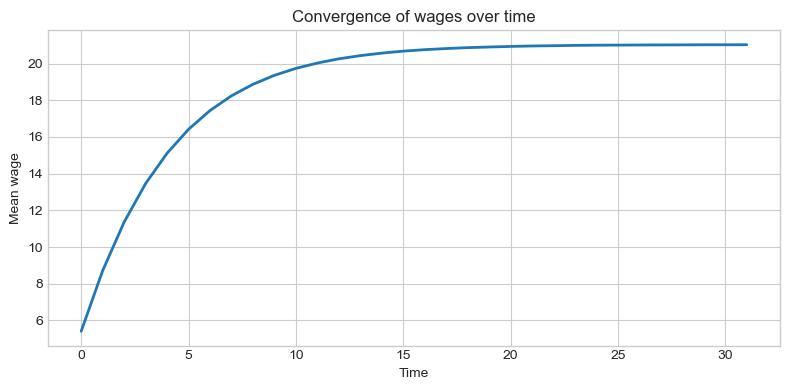

C:\Users\Peter\AppData\Local\Temp\ipykernel_18892\565580534.py:18: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)


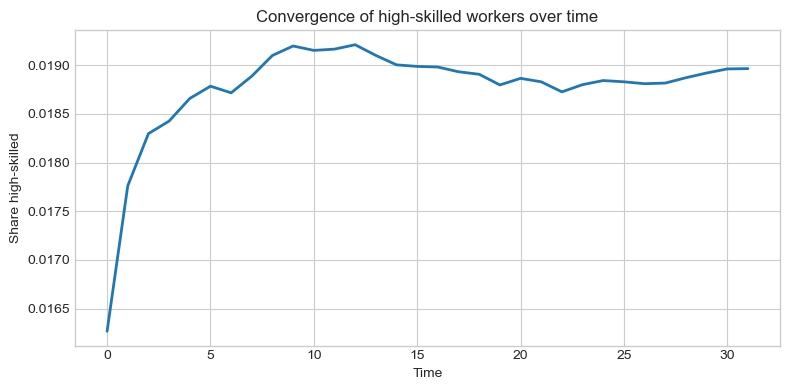

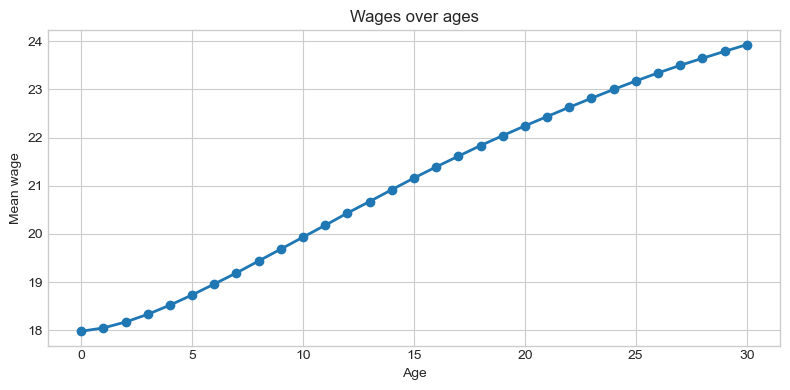

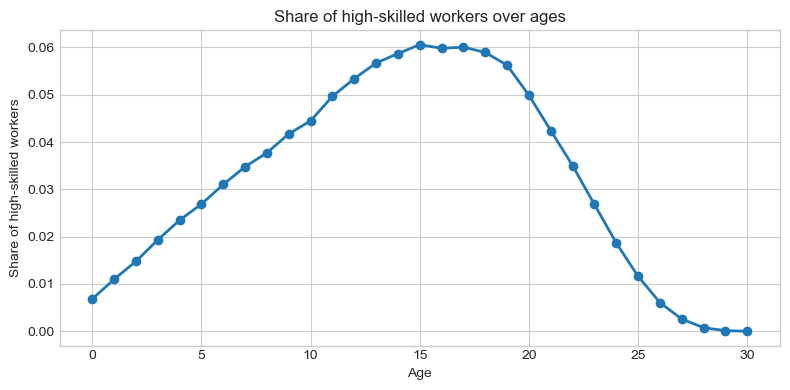

In [17]:
t = np.count_nonzero(~np.isnan(model.sol.age[0,:])) - 1

plt.style.use("seaborn-v0_8-whitegrid")

age_groups = range(model.par.n)

# 1. Convergence of wages over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)
plt.title("Convergence of wages over time")
plt.xlabel("Time")
plt.ylabel("Mean wage")
plt.tight_layout()
plt.show()

# 2. Convergence of high-skilled workers over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)
plt.title("Convergence of high-skilled workers over time")
plt.xlabel("Time")
plt.ylabel("Share high-skilled")
plt.tight_layout()
plt.show()

# 3. Wages over ages
means = [
    np.nanmean(model.sol.wage[:, t][model.sol.age[:, t] == i])
    for i in age_groups
]

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), means, marker="o", linewidth=2)
plt.title("Wages over ages")
plt.xlabel("Age")
plt.ylabel("Mean wage")
plt.tight_layout()
plt.show()

# 4. Share of high-skilled workers over ages, weighted by cohort mass
valid = ~np.isnan(model.sol.age[:, t])
l_h_mask = valid & (model.sol.l_h[:, t] == 1)

count = [
    np.nansum(model.sol.mass[l_h_mask & (model.sol.age[:, t] == i), t])
    for i in age_groups
]

count = np.array(count) / np.sum(count)

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), count, marker="o", linewidth=2)
plt.title("Share of high-skilled workers over ages")
plt.xlabel("Age")
plt.ylabel("Share of high-skilled workers")
plt.tight_layout()
plt.show()